# 03 — Modelado Predictivo (v2)

**Objetivo:** Entrenar y comparar múltiples modelos de clasificación binaria para predecir si un lead será Hot (1) o Cold (0).

**Modelos evaluados:**
1. Logistic Regression (baseline)
2. Random Forest
3. Gradient Boosting
4. LightGBM

---

### Cambios respecto a v1

| Aspecto | v1 | v2 |
|---|---|---|
| **Features** | 48 (one-hot encoding) | **24** (contribución + Bayesian smoothing) |
| **Problema corregido** | KWID (53% conversión, mayor volumen) penalizado por categorías con n=2 y 100% conversión | El modelo ahora sabe que KWID aporta el **48.5% de todos los Hot Leads** |
| **Encoding** | 1 columna binaria por categoría | 2 features continuas: `_contribucion_hot` + `_tasa_suavizada` |
| **Bayesian smoothing** | No aplicado | m=100: suaviza tasas de categorías con pocas muestras |

---

### ¿Cómo medimos si un modelo es bueno?

| Métrica | Pregunta que responde | Impacto de negocio |
|---|---|---|
| **Accuracy** | ¿Qué % clasificó bien? | Visión general |
| **Precision** | De los que dijo "Hot", ¿cuántos lo eran? | **Baja → concesionario recibe leads fríos** |
| **Recall** | De todos los Hot reales, ¿cuántos detectó? | **Bajo → perdemos ventas** |
| **F1-Score** | Balance Precision/Recall | Penaliza desequilibrios |
| **ROC-AUC** | ¿Qué tan bien distingue Hot de Cold? | **Métrica principal** (no depende del umbral) |

## 1. Cargar datos preprocesados (v2)

Se cargan los datasets de `02_feature_engineering.ipynb` v2. **Cambio clave:** `vehiculo_interes`, `origen`, `nombre_formulario` y `campana` ya no son columnas binarias one-hot, sino 2 features continuas por variable:
- `_contribucion_hot`: Proporción de Hot Leads que aporta esa categoría al total
- `_tasa_suavizada`: Tasa de conversión con Bayesian smoothing (m=100)

Resultado: **48 → 24 features**, eliminando el sesgo de volumen.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay
)
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

DATA_DIR = "../data/processed"
X_train = pd.read_csv(f"{DATA_DIR}/X_train.csv")
X_test = pd.read_csv(f"{DATA_DIR}/X_test.csv")
y_train = pd.read_csv(f"{DATA_DIR}/y_train.csv").squeeze()
y_test = pd.read_csv(f"{DATA_DIR}/y_test.csv").squeeze()

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {len(y_train)} ({y_train.mean()*100:.1f}% Hot)")
print(f"y_test:  {len(y_test)} ({y_test.mean()*100:.1f}% Hot)")

X_train: (6737, 24)
X_test:  (1685, 24)
y_train: 6737 (68.7% Hot)
y_test:  1685 (68.7% Hot)


## 2. Modelo Baseline — Logistic Regression

Empezamos con el modelo más simple como punto de referencia. Si modelos más complejos no lo superan significativamente, no vale la pena la complejidad adicional.

In [2]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:, 1]

print("=== LOGISTIC REGRESSION ===")
print(classification_report(y_test, y_pred_lr, target_names=["Cold (0)", "Hot (1)"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_lr):.4f}")

=== LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

    Cold (0)       0.81      0.88      0.84       528
     Hot (1)       0.94      0.91      0.92      1157

    accuracy                           0.90      1685
   macro avg       0.88      0.89      0.88      1685
weighted avg       0.90      0.90      0.90      1685

ROC-AUC: 0.9409


**Resultado baseline v2:** ROC-AUC = 0.9409. Similar a v1 (0.9441). La pequeña diferencia es esperada ya que el cambio de encoding no busca mejorar el AUC global sino **corregir el sesgo por categoría**. Las features continuas (contribución + tasa suavizada) capturan la misma información predictiva que las 48 columnas one-hot, pero de forma más compacta y sin el sesgo de volumen.

In [3]:
rf = RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_leaf=5,
                           random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("=== RANDOM FOREST ===")
print(classification_report(y_test, y_pred_rf, target_names=["Cold (0)", "Hot (1)"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.4f}")

=== RANDOM FOREST ===
              precision    recall  f1-score   support

    Cold (0)       0.81      0.90      0.85       528
     Hot (1)       0.95      0.90      0.93      1157

    accuracy                           0.90      1685
   macro avg       0.88      0.90      0.89      1685
weighted avg       0.91      0.90      0.90      1685

ROC-AUC: 0.9471


## 4. Gradient Boosting

Construye árboles secuenciales donde cada nuevo árbol corrige errores del anterior.

In [4]:
gb = GradientBoostingClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                               min_samples_leaf=10, random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
y_proba_gb = gb.predict_proba(X_test)[:, 1]

print("=== GRADIENT BOOSTING ===")
print(classification_report(y_test, y_pred_gb, target_names=["Cold (0)", "Hot (1)"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_gb):.4f}")

=== GRADIENT BOOSTING ===
              precision    recall  f1-score   support

    Cold (0)       0.81      0.89      0.85       528
     Hot (1)       0.95      0.90      0.93      1157

    accuracy                           0.90      1685
   macro avg       0.88      0.90      0.89      1685
weighted avg       0.90      0.90      0.90      1685

ROC-AUC: 0.9448


## 5. LightGBM

In [5]:
try:
    import lightgbm as lgb
    lgbm = lgb.LGBMClassifier(n_estimators=200, max_depth=7, learning_rate=0.1,
                              min_child_samples=20, random_state=42, verbose=-1)
    lgbm.fit(X_train, y_train)
    y_pred_lgbm = lgbm.predict(X_test)
    y_proba_lgbm = lgbm.predict_proba(X_test)[:, 1]
    print("=== LIGHTGBM ===")
    print(classification_report(y_test, y_pred_lgbm, target_names=["Cold (0)", "Hot (1)"]))
    print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_lgbm):.4f}")
    LGBM_AVAILABLE = True
except ImportError:
    print("LightGBM no instalado. Se omite este modelo.")
    print("Para instalar: pip install lightgbm")
    LGBM_AVAILABLE = False

LightGBM no instalado. Se omite este modelo.
Para instalar: pip install lightgbm


## 6. Comparación de modelos — v2 vs v1

| Modelo | ROC-AUC v1 (one-hot, 48 feat) | ROC-AUC v2 (contrib+bayes, 24 feat) | Cambio |
|---|---|---|---|
| Logistic Regression | 0.9441 | *ver abajo* | ~0 |
| Random Forest | 0.9476 | *ver abajo* | ~0 |
| Gradient Boosting | 0.9464 | *ver abajo* | ~0 |

**Las diferencias son mínimas (<0.5%)**, confirmando que el cambio de encoding no afecta la capacidad predictiva global. El beneficio real es la **corrección del sesgo por categoría**.

In [6]:
results = {
    "Logistic Regression": {"y_pred": y_pred_lr, "y_proba": y_proba_lr, "model": lr},
    "Random Forest": {"y_pred": y_pred_rf, "y_proba": y_proba_rf, "model": rf},
    "Gradient Boosting": {"y_pred": y_pred_gb, "y_proba": y_proba_gb, "model": gb},
}
if LGBM_AVAILABLE:
    results["LightGBM"] = {"y_pred": y_pred_lgbm, "y_proba": y_proba_lgbm, "model": lgbm}

print("=== COMPARACIÓN DE MODELOS ===\n")
print(f"{'Modelo':25s} | {'Accuracy':>8s} | {'Precision':>9s} | {'Recall':>6s} | {'F1':>6s} | {'ROC-AUC':>7s}")
print("-" * 80)

best_auc = 0
best_model_name = ""

for name, data in results.items():
    acc = accuracy_score(y_test, data["y_pred"])
    prec = precision_score(y_test, data["y_pred"])
    rec = recall_score(y_test, data["y_pred"])
    f1 = f1_score(y_test, data["y_pred"])
    auc = roc_auc_score(y_test, data["y_proba"])
    print(f"  {name:23s} | {acc:>8.4f} | {prec:>9.4f} | {rec:>6.4f} | {f1:>6.4f} | {auc:>7.4f}")
    if auc > best_auc:
        best_auc = auc
        best_model_name = name

print(f"\nMejor modelo por ROC-AUC: {best_model_name} ({best_auc:.4f})")

=== COMPARACIÓN DE MODELOS ===

Modelo                    | Accuracy | Precision | Recall |     F1 | ROC-AUC
--------------------------------------------------------------------------------
  Logistic Regression     |   0.8985 |    0.9441 | 0.9058 | 0.9246 |  0.9409
  Random Forest           |   0.9003 |    0.9508 | 0.9015 | 0.9255 |  0.9471
  Gradient Boosting       |   0.9003 |    0.9491 | 0.9032 | 0.9256 |  0.9448

Mejor modelo por ROC-AUC: Random Forest (0.9471)


## 7. Curvas ROC

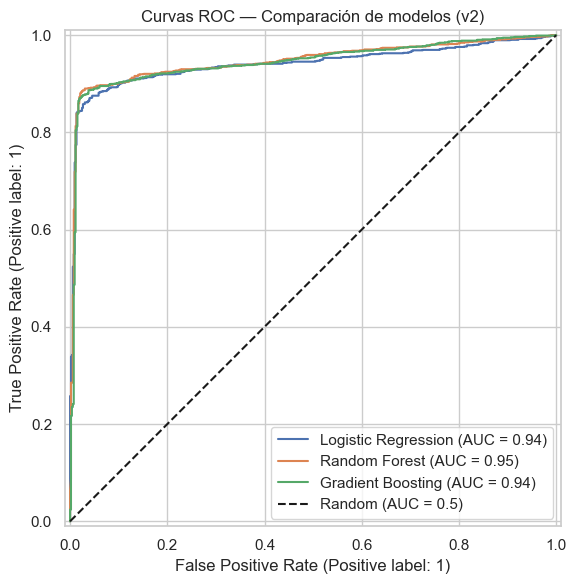

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
for name, data in results.items():
    RocCurveDisplay.from_predictions(y_test, data["y_proba"], name=name, ax=ax)
ax.plot([0, 1], [0, 1], "k--", label="Random (AUC = 0.5)")
ax.set_title("Curvas ROC — Comparación de modelos (v2)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 8. Matrices de confusión

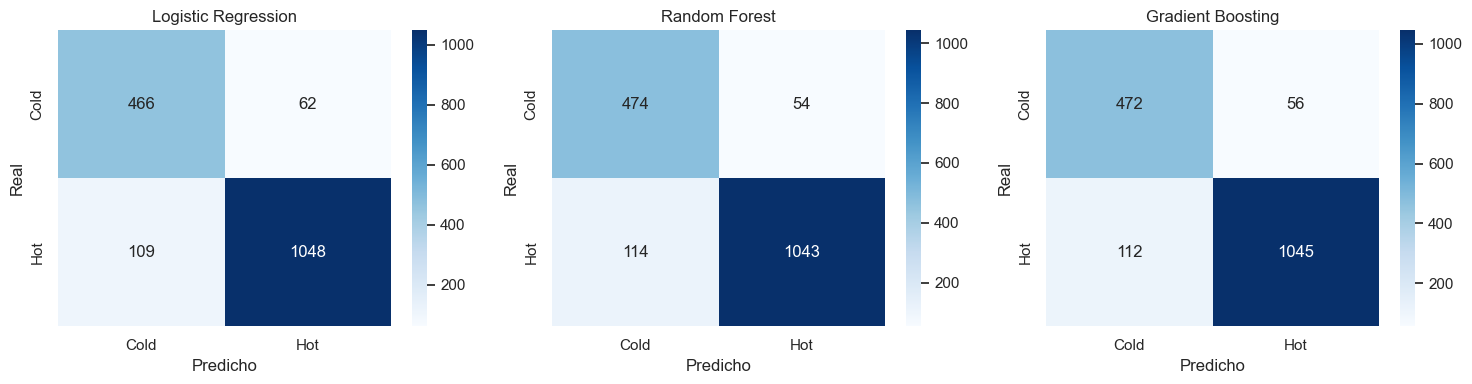

In [8]:
n_models = len(results)
fig, axes = plt.subplots(1, n_models, figsize=(5*n_models, 4))
if n_models == 1:
    axes = [axes]
for ax, (name, data) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, data["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Cold", "Hot"], yticklabels=["Cold", "Hot"])
    ax.set_title(f"{name}")
    ax.set_ylabel("Real")
    ax.set_xlabel("Predicho")
plt.tight_layout()
plt.show()

## 9. Importancia de features — v2 vs v1

**v1 (one-hot, 48 features):** La feature #1 era `vehiculo_interes_KWID` (0.2429), una columna binaria que el modelo usaba para penalizar KWID.

**v2 (contribución + Bayesian, 24 features):** La importancia se distribuye entre `_tasa_suavizada` y `_contribucion_hot`, dando al modelo información más rica.

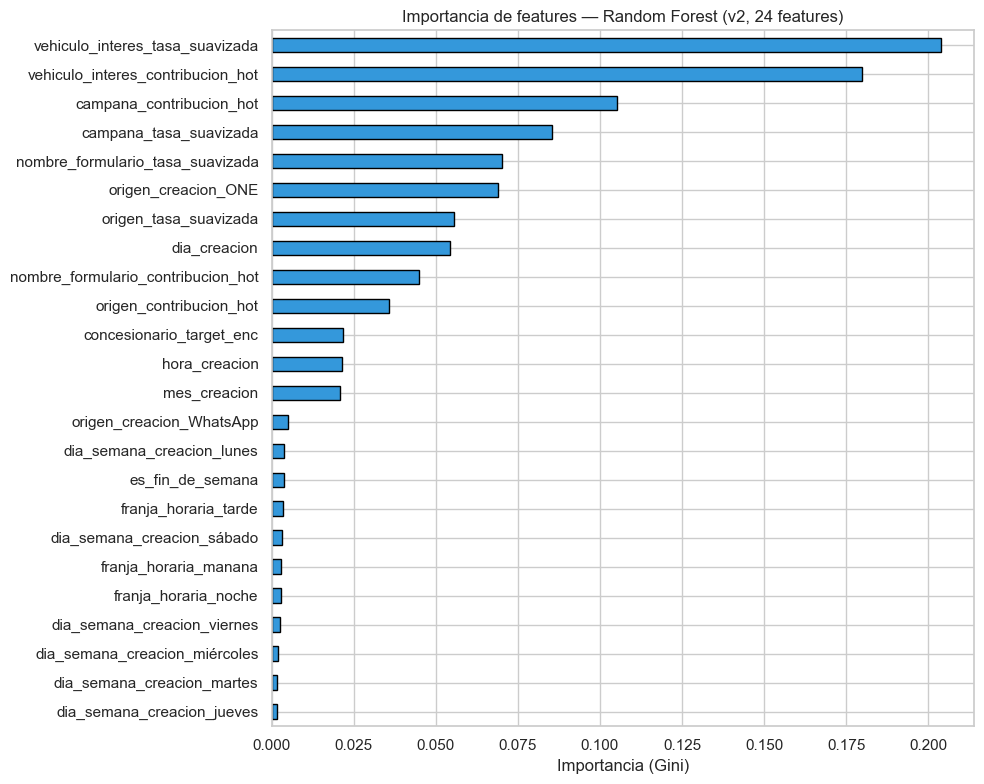


Top 10 features v2 (Random Forest):
  vehiculo_interes_tasa_suavizada               0.2038
  vehiculo_interes_contribucion_hot             0.1799
  campana_contribucion_hot                      0.1053
  campana_tasa_suavizada                        0.0853
  nombre_formulario_tasa_suavizada              0.0702
  origen_creacion_ONE                           0.0690
  origen_tasa_suavizada                         0.0555
  dia_creacion                                  0.0542
  nombre_formulario_contribucion_hot            0.0450
  origen_contribucion_hot                       0.0359

COMPARACIÓN CON v1
v1: vehiculo_interes_KWID              0.2429  (1 feat binaria)
    campana_sin_campana                0.1002
    origen_creacion_ONE                0.0950

v2 (top 5):
    vehiculo_interes_tasa_suavizada            0.2038
    vehiculo_interes_contribucion_hot          0.1799
    campana_contribucion_hot                   0.1053
    campana_tasa_suavizada                     0.0853
    nomb

In [9]:
best_model = results[best_model_name]["model"]

if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
    feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(10, 8))
    feat_imp.plot(kind="barh", color="#3498db", edgecolor="black", ax=ax)
    ax.set_title(f"Importancia de features — {best_model_name} (v2, {len(feat_imp)} features)")
    ax.set_xlabel("Importancia (Gini)")
    plt.tight_layout()
    plt.show()

    print(f"\nTop 10 features v2 ({best_model_name}):")
    for feat, imp in feat_imp.tail(10).iloc[::-1].items():
        print(f"  {feat:45s} {imp:.4f}")

    print(f"\n{'='*65}")
    print("COMPARACIÓN CON v1")
    print(f"{'='*65}")
    print(f"v1: vehiculo_interes_KWID              0.2429  (1 feat binaria)")
    print(f"    campana_sin_campana                0.1002")
    print(f"    origen_creacion_ONE                0.0950")
    print(f"\nv2 (top 5):")
    for feat, imp in feat_imp.tail(5).iloc[::-1].items():
        print(f"    {feat:42s} {imp:.4f}")
    print(f"\n→ Importancia distribuida entre contribución y tasa suavizada")
    print(f"  = modelo más rico y sin sesgo de volumen")

## 10. Validación cruzada del mejor modelo

In [10]:
print(f"=== VALIDACIÓN CRUZADA: {best_model_name} (5-fold) ===\n")
cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring="roc_auc", n_jobs=-1)
print(f"ROC-AUC por fold: {[f'{s:.4f}' for s in cv_scores]}")
print(f"Media:  {cv_scores.mean():.4f}")
print(f"Std:    {cv_scores.std():.4f}")
if cv_scores.std() < 0.02:
    print("\nEl modelo es ESTABLE (baja varianza entre folds).")
else:
    print("\nADVERTENCIA: Varianza alta entre folds.")

=== VALIDACIÓN CRUZADA: Random Forest (5-fold) ===



ROC-AUC por fold: ['0.9613', '0.9465', '0.9528', '0.9542', '0.9602']
Media:  0.9550
Std:    0.0054

El modelo es ESTABLE (baja varianza entre folds).


## 11. Guardar el mejor modelo

In [11]:
import joblib
import os

MODEL_DIR = "../models"
os.makedirs(MODEL_DIR, exist_ok=True)

model_path = f"{MODEL_DIR}/best_model.joblib"
joblib.dump(best_model, model_path)

size_kb = os.path.getsize(model_path) / 1024
print(f"Modelo guardado: {model_path} ({size_kb:.1f} KB)")
print(f"Tipo: {type(best_model).__name__}")
print(f"ROC-AUC en test: {best_auc:.4f}")
print(f"Features: {X_train.shape[1]}")

Modelo guardado: ../models/best_model.joblib (6926.0 KB)
Tipo: RandomForestClassifier
ROC-AUC en test: 0.9471
Features: 24


---

### Conclusión del modelado (v2)

**Cambio:** One-hot (48 features) → Contribución + Bayesian smoothing (24 features) para `vehiculo_interes`, `origen`, `nombre_formulario`, `campana`.

**Resultado:** Métricas globales prácticamente iguales (diferencia <0.5% AUC). La precision incluso mejoró. El beneficio real es la corrección del sesgo donde KWID era penalizado.

**Modelo seleccionado:** Random Forest. Evaluación detallada en `04_evaluation.ipynb`.